# PoseBusters Benchmark Set — Distribution & Mapping Analysis

A descriptive analysis of the **PoseBusters Benchmark set** (428 protein–ligand
complexes) used to validate molecular docking / pose-prediction methods.

> Buttenschoen M, Morris GM, Deane CM. *PoseBusters: AI-based docking methods fail
> to generate physically valid poses or generalise to novel sequences.*
> **Chem. Sci.**, 2024, 15, 3130 — https://pubs.rsc.org/en/content/articlehtml/2024/sc/d3sc04185a
> · code: https://github.com/maabuu/posebusters

**Each entry** `PDB_CCD/` contains four files:

| file | content |
|------|---------|
| `*_protein.pdb` | receptor without the ligand-of-interest, no solvent, **with cofactors** |
| `*_ligands.sdf` | *all* crystallographic instances of the ligand of interest |
| `*_ligand.sdf` | one chosen instance — the crystal "answer" pose / binding-site marker |
| `*_ligand_start_conf.sdf` | one RDKit **ETKDGv3 + UFF** generated start conformer |

**What this notebook does**

1. Parses all 428 ligands (RDKit) and proteins (raw PDB) into a single feature table.
2. Maps the **univariate distributions** of ~20 ligand attributes (heavy atoms, MW,
   rotatable bonds, H-bond donors/acceptors, TPSA, logP, rings, Fsp³, QED, formal
   charge, stereocentres, halogen/S/P content …).
3. Characterises **drug-likeness** (Lipinski Ro5, QED) and **elemental composition**.
4. Maps **joint distributions** (correlation heat-map, 2-D scatter mappings, pairplot).
5. Profiles the **receptors** (residues, chains, heavy atoms, cofactors) and relates
   pocket/protein size to ligand size.
6. Quantifies **conformer-generation difficulty** via start-conformer → crystal RMSD.

All derived figures are written to `PoseBusters_Benchmark_Analysis/figures/` and the
full feature table to `PoseBusters_Benchmark_Analysis/ligand_protein_features.csv`.


## 1 · Setup

In [1]:
import os, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdMolDescriptors, QED, Crippen, rdMolAlign
RDLogger.DisableLog("rdApp.*")          # silence RDKit parse chatter
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.titleweight": "bold"})
PALETTE = "viridis"

DATA_DIR = Path("Data/PoseBuster Benchmark Set")
OUT_DIR  = Path("PoseBusters_Benchmark_Analysis")
FIG_DIR  = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name, tight=True):
    fig = plt.gcf()
    if tight:
        fig.tight_layout()
    # The panel letters sit OUTSIDE the axes and are excluded from the layout
    # (set_in_layout(False)). Pass the layout's DEFAULT extra artists (suptitle,
    # figure legends, …) PLUS the panel letters, so the bbox_inches='tight' crop
    # still includes everything and nothing is cut off. (bbox_extra_artists
    # REPLACES the default list, so the defaults must be re-added explicitly.)
    extra = fig.get_default_bbox_extra_artists() + [
        a for ax in fig.axes for a in ax.get_children()
        if a.get_gid() == "panel_label"]
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", bbox_extra_artists=extra)

def _label_panels(axes, fontsize=14):
    """Tag each visible subplot with (A), (B), (C)… in reading order
    (top-left → bottom-right), placed in the MARGIN just outside each plot's
    top-left corner (never on top of the data).

    The letter is excluded from the layout engines (``set_in_layout(False)``)
    so it cannot reflow or distort the plot area — verified that axes positions
    are byte-identical with vs without the label under tight_layout and
    constrained_layout — and it is tagged ``gid='panel_label'`` so ``savefig``
    adds it to the bbox_inches='tight' crop and it is never cut off. Accepts a
    2-D/1-D Axes array, a list, or a single Axes; hidden axes are skipped."""
    if hasattr(axes, "ravel"):
        flat = list(axes.ravel())
    elif isinstance(axes, (list, tuple)):
        flat = list(axes)
    else:
        flat = [axes]
    i = 0
    for ax in flat:
        if ax is None or not ax.get_visible():
            continue
        ann = ax.annotate(f"({chr(65 + i % 26)})", xy=(0, 1), xycoords="axes fraction",
                          xytext=(-6, 6), textcoords="offset points",
                          fontweight="bold", fontsize=fontsize, ha="right", va="bottom",
                          annotation_clip=False, gid="panel_label")
        ann.set_in_layout(False)   # never reflow / distort the axes
        ann.set_clip_on(False)
        i += 1

# Full, spelled-out names for every descriptor — used for axis labels, titles
# and heat-map ticks so that no abbreviation (TPSA, QED, MW, logP, …) appears
# in any figure. Includes units where applicable.
NICE = {
    "heavy_atoms":      "Number of Heavy Atoms",
    "mw":               "Molecular Weight (Dalton)",
    "rot_bonds":        "Number of Rotatable Bonds",
    "hbd":              "Number of Hydrogen-Bond Donors",
    "hba":              "Number of Hydrogen-Bond Acceptors",
    "tpsa":             "Topological Polar Surface Area (Å²)",
    "logp":             "Octanol–Water Partition Coefficient (calculated)",
    "n_rings":          "Number of Rings",
    "n_arom_rings":     "Number of Aromatic Rings",
    "fsp3":             "Fraction of sp³-Hybridised Carbons",
    "qed":              "Quantitative Estimate of Drug-Likeness",
    "formal_charge":    "Net Formal Charge",
    "n_stereo":         "Number of Stereocentres",
    "n_heteroatoms":    "Number of Heteroatoms (non-Carbon, non-Hydrogen)",
    "n_halogens":       "Number of Halogen Atoms",
    "n_element_types":  "Number of Distinct Element Types",
    "n_residues":       "Number of Resolved Residues",
    "n_chains":         "Number of Chains",
    "prot_heavy_atoms": "Number of Protein Heavy Atoms",
    "n_cofactor_types": "Number of Distinct Cofactor Types",
    "startconf_rmsd":   "Root-Mean-Square Deviation to Crystal Pose (Å)",
}
def nice(col):
    """Spelled-out, no-abbreviation label for a descriptor column name."""
    return NICE.get(col, col)

# Compact (still fully spelled-out, no-abbreviation) names for dense figures
# such as the pairplot and the PCA biplot, where the units-bearing NICE labels
# would overlap. No acronyms are used here either.
SHORT = {
    "heavy_atoms":     "Heavy Atoms",
    "mw":              "Molecular Weight",
    "rot_bonds":       "Rotatable Bonds",
    "hbd":             "Hydrogen-Bond Donors",
    "hba":             "Hydrogen-Bond Acceptors",
    "tpsa":            "Polar Surface Area",
    "logp":            "Partition Coefficient",
    "n_rings":         "Rings",
    "n_arom_rings":    "Aromatic Rings",
    "fsp3":            "sp³ Carbon Fraction",
    "qed":             "Drug-Likeness",
    "formal_charge":   "Formal Charge",
    "n_stereo":        "Stereocentres",
    "n_heteroatoms":   "Heteroatoms",
    "n_halogens":      "Halogen Atoms",
    "n_element_types": "Element Types",
}
def short(col):
    """Compact, no-abbreviation label for dense annotations (pairplot, biplot)."""
    return SHORT.get(col, NICE.get(col, col))

# Restrict the analysis to the curated subset listed in this ID file
# (one PDB_CCD per line, matching the complex folder names).
ID_FILE = DATA_DIR / "posebusters_pdb_ccd_ids.txt"
requested_set = {ln.strip() for ln in ID_FILE.read_text().splitlines() if ln.strip()}
on_disk = {p.name for p in DATA_DIR.iterdir() if p.is_dir()}
entries = sorted(requested_set & on_disk)
missing = sorted(requested_set - on_disk)
print(f"Requested IDs in {ID_FILE.name}: {len(requested_set)}")
print(f"Matched complex folders on disk : {len(entries)}")
if missing:
    print(f"WARNING: {len(missing)} requested ID(s) have no folder on disk: "
          f"{', '.join(missing[:10])}{' ...' if len(missing) > 10 else ''}")

Requested IDs in posebusters_pdb_ccd_ids.txt: 308
Matched complex folders on disk : 308


## 2 · Feature extraction

For every complex we compute a panel of RDKit 2-D/physchem descriptors on the crystal
ligand, count basic receptor properties straight from the PDB record columns, and align
the generated start conformer onto the crystal pose (symmetry-corrected `GetBestRMS`,
falling back to an explicit-H-stripped comparison).

In [2]:
HALOGENS = {"F", "Cl", "Br", "I"}
METALS   = {"Na","K","Mg","Ca","Zn","Fe","Mn","Cu","Ni","Co","Mo","Cd","Hg",
            "Pt","Ru","Ir","Au","Ag","V","W","Se"}
# standard amino-acid residue names (incl. common modified residues)
AA3 = set("ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER "
          "THR TRP TYR VAL MSE SEC PYL".split())

def ligand_features(mol):
    elems = [a.GetSymbol() for a in mol.GetAtoms()]
    eset  = set(elems)
    return dict(
        mw            = Descriptors.MolWt(mol),
        heavy_atoms   = mol.GetNumHeavyAtoms(),
        rot_bonds     = rdMolDescriptors.CalcNumRotatableBonds(mol),
        hbd           = rdMolDescriptors.CalcNumHBD(mol),
        hba           = rdMolDescriptors.CalcNumHBA(mol),
        tpsa          = rdMolDescriptors.CalcTPSA(mol),
        logp          = Crippen.MolLogP(mol),
        n_rings       = rdMolDescriptors.CalcNumRings(mol),
        n_arom_rings  = rdMolDescriptors.CalcNumAromaticRings(mol),
        fsp3          = rdMolDescriptors.CalcFractionCSP3(mol),
        qed           = QED.qed(mol),
        formal_charge = Chem.GetFormalCharge(mol),
        n_stereo      = rdMolDescriptors.CalcNumAtomStereoCenters(mol),
        n_heteroatoms = rdMolDescriptors.CalcNumHeteroatoms(mol),
        n_halogens    = sum(e in HALOGENS for e in elems),
        n_element_types = len(eset),
        has_halogen   = int(bool(eset & HALOGENS)),
        has_sulfur    = int("S" in eset),
        has_phosphorus= int("P" in eset),
        has_metal     = int(bool(eset & METALS)),
    )

def protein_features(pdb_path):
    atoms = hetatm = heavy = 0
    chains, aa_res, het_comps = set(), set(), set()
    with open(pdb_path) as fh:
        for ln in fh:
            rec = ln[:6].strip()
            if rec not in ("ATOM", "HETATM"):
                continue
            atoms += 1
            if ln[76:78].strip() != "H":
                heavy += 1
            chains.add(ln[21])
            resn = ln[17:20].strip()
            if rec == "HETATM":
                hetatm += 1
                if resn != "HOH":
                    het_comps.add(resn)
            else:
                aa_res.add((ln[21], ln[22:27].strip()))
    return dict(
        prot_atoms       = atoms,
        prot_heavy_atoms = heavy,
        prot_hetatm      = hetatm,
        n_chains         = len(chains),
        n_residues       = len(aa_res),
        n_cofactor_types = len(het_comps),
    )

def startconf_rmsd(start_mol, ref_mol):
    if start_mol is None or ref_mol is None:
        return np.nan
    for a, b in ((start_mol, ref_mol),
                 (Chem.RemoveHs(Chem.Mol(start_mol)), Chem.RemoveHs(Chem.Mol(ref_mol)))):
        try:
            return rdMolAlign.GetBestRMS(Chem.Mol(a), Chem.Mol(b))
        except Exception:
            continue
    return np.nan


In [3]:
CACHE = OUT_DIR / "ligand_protein_features.csv"

def build_table():
    rows = []
    for d in entries:
        pdb_id, ccd = d.split("_", 1)
        folder = DATA_DIR / d
        mol   = Chem.MolFromMolFile(str(folder / f"{d}_ligand.sdf"))
        start = Chem.MolFromMolFile(str(folder / f"{d}_ligand_start_conf.sdf"))
        if mol is None:                       # should not happen for this set
            continue
        n_inst = sum(1 for _ in Chem.SDMolSupplier(str(folder / f"{d}_ligands.sdf")))
        row = dict(entry=d, pdb_id=pdb_id, ccd=ccd, n_instances=n_inst)
        row.update(ligand_features(mol))
        row["startconf_rmsd"] = startconf_rmsd(start, mol)
        row.update(protein_features(folder / f"{d}_protein.pdb"))
        rows.append(row)
    return pd.DataFrame(rows)

t0 = time.time()
df = build_table()
df.to_csv(CACHE, index=False)
print(f"Built feature table for {len(df)} complexes in {time.time()-t0:.1f}s "
      f"-> {CACHE}")
df.head()


Built feature table for 308 complexes in 2.7s -> PoseBusters_Benchmark_Analysis/ligand_protein_features.csv


,entry,pdb_id,ccd,n_instances,mw,heavy_atoms,rot_bonds,hbd,hba,tpsa,...,has_sulfur,has_phosphorus,has_metal,startconf_rmsd,prot_atoms,prot_heavy_atoms,prot_hetatm,n_chains,n_residues,n_cofactor_types
0,5SAK_ZRY,5SAK,ZRY,1,236.278,18,2,3,3,60.27,...,0,0,0,NaN,4702,2411,35,1,330,3
1,5SB2_1K2,5SB2,1K2,1,417.896,30,6,2,3,67.01,...,0,0,0,2.085310,2290,2290,5,1,286,1
2,5SD5_HWI,5SD5,HWI,1,401.467,29,9,3,8,136.82,...,0,0,0,1.480474,1365,1365,69,1,166,3
3,5SIS_JSM,5SIS,JSM,1,431.500,32,7,2,7,96.56,...,0,0,0,1.611907,2572,2572,2,1,316,2
4,6M2B_EZO,6M2B,EZO,1,371.849,25,5,1,5,65.79,...,1,0,0,2.424230,2834,2834,42,1,365,2


## 2b · JKU reference ligands (overlay)

Five named, geometry-optimised ligands from `Drugs/JKU/` are loaded with the **same**
`ligand_features()` descriptors and overlaid on the ligand-attribute figures (Sec 4, 5, 7)
for context. They carry no receptor / crystal pose, so they do **not** appear in the
receptor-profile (Sec 8) or start-conf RMSD (Sec 9) figures.

In [4]:
JKU_DIR = Path("Drugs/JKU")
JKU_FILES = {
    "2abp-NH2":          "2abp-nh2-OPT.sdf",
    # "2abp-NH3+":         "2abp-nh3p-OPT.sdf",
    "Synta-66":          "Synta-66-OPT-Singlet.sdf",
    # CORRECTED 2026-08-16: the file named "deprot" is NOT the -1 phenolate.
    # RDKit parses it as a neutral RADICAL (C18H11F5N3O2, 1 radical electron,
    # formal charge 0) - the retired species. The compound actually docked and
    # reported throughout the thesis is the neutral GSK-7975A below.
    "GSK-7975A":         "gsk7975a-prot-OPT.sdf",
    # "GSK7975A (deprot-radical, retired)": "gsk7975a-deprot-OPT.sdf",
}
JKU_COLORS = dict(zip(JKU_FILES, sns.color_palette("tab10", len(JKU_FILES))))
# distinct marker per ligand so overlapping points stay separable by shape too
JKU_MARKERS = dict(zip(JKU_FILES, ["*", "P", "X", "D", "^", "v", "s", "o"]))

def _load_jku_mol(path):
    """Robust SDF loader: assign the missing +1 charge to over-valent N/O.
    OpenBabel-generated files (e.g. the protonated amine) don't encode the
    protonation state, which otherwise trips RDKit's valence check."""
    m = Chem.MolFromMolFile(str(path), sanitize=False)
    if m is None:
        return None
    m.UpdatePropertyCache(strict=False)
    for atom in m.GetAtoms():
        ev, sym, chg = atom.GetExplicitValence(), atom.GetSymbol(), atom.GetFormalCharge()
        if chg == 0 and ((sym == "N" and ev == 4) or (sym == "O" and ev == 3)):
            atom.SetFormalCharge(1)
    try:
        Chem.SanitizeMol(m)
        Chem.AssignStereochemistryFrom3D(m)
    except Exception:
        return None
    # BASIS FIX 2026-08-19: sanitize=False suppresses RDKit's implicit RemoveHs, so this
    # molecule kept its explicit hydrogens while the benchmark loader (Chem.MolFromMolFile
    # with the default removeHs=True) is hydrogen-suppressed. Exactly two of the 16
    # descriptors are basis-dependent and were inflated for the JKU ligands alone:
    # rot_bonds (the terminal C-NH2, phenol C-OH and methoxy O-CH3 bonds the standard
    # descriptor excludes) and n_element_types (H counted as an element). Stereochemistry is
    # assigned above, on the explicit-H molecule, before the hydrogens are removed.
    return Chem.RemoveHs(m)

def build_jku_table():
    rows = []
    for label, fn in JKU_FILES.items():
        mol = _load_jku_mol(JKU_DIR / fn)
        if mol is None:
            print(f"WARNING: could not parse JKU ligand {fn}")
            continue
        row = dict(label=label)
        row.update(ligand_features(mol))
        rows.append(row)
    j = pd.DataFrame(rows).set_index("label")
    j["ro5_violations"] = ((j.mw>500).astype(int) + (j.logp>5).astype(int)
                           + (j.hbd>5).astype(int) + (j.hba>10).astype(int))
    j["ro5_pass"] = j.ro5_violations <= 1
    return j

jku_df = build_jku_table()
print(f"Loaded {len(jku_df)}/{len(JKU_FILES)} JKU reference ligands")

def overlay_jku_vlines(ax, col):
    """Dashed vertical line per JKU ligand on a 1-D distribution axis.
    A coloured dot is placed at a *stepped* height on each line so that lines
    coinciding with the median or with each other remain individually visible."""
    if col not in jku_df.columns:
        return
    vals = jku_df[col]
    # widen the x-range if any JKU value falls outside the benchmark spread
    lo, hi = ax.get_xlim()
    span = (hi - lo) or 1.0
    ax.set_xlim(min(lo, vals.min() - 0.02*span), max(hi, vals.max() + 0.02*span))
    ymin, ymax = ax.get_ylim()
    n = len(vals)
    for k, (label, val) in enumerate(vals.items()):
        ax.axvline(val, color=JKU_COLORS[label], lw=1.4, ls=(0, (4, 2)),
                   alpha=.85, zorder=5)
        # step the marker down from the top; coincident lines -> stacked dots
        yk = ymin + (ymax - ymin) * (0.96 - 0.085 * (k % n))
        ax.plot(val, yk, marker=JKU_MARKERS[label], color=JKU_COLORS[label],
                markeredgecolor="black", markeredgewidth=.5, markersize=7, zorder=6)

def _fan_offsets(n, radius):
    """Unit-circle offsets used to fan out coincident scatter markers."""
    if n == 1:
        return [(0.0, 0.0)]
    ang = np.linspace(0, 2*np.pi, n, endpoint=False)
    return [(radius*np.cos(a), radius*np.sin(a)) for a in ang]

def overlay_jku_points(ax, x, y):
    """Marker per JKU ligand on a 2-D scatter axis. Near-identical ligands
    (e.g. protonated/deprotonated pairs) are fanned around their shared point
    with thin connectors to the true location so none is hidden."""
    if x not in jku_df.columns or y not in jku_df.columns:
        return
    pts = [(label, float(r[x]), float(r[y])) for label, r in jku_df.iterrows()]
    # widen limits so out-of-range JKU points are not clipped
    xs = [p[1] for p in pts]; ys = [p[2] for p in pts]
    (xlo, xhi), (ylo, yhi) = ax.get_xlim(), ax.get_ylim()
    xspan = (xhi - xlo) or 1.0; yspan = (yhi - ylo) or 1.0
    ax.set_xlim(min(xlo, min(xs) - 0.04*xspan), max(xhi, max(xs) + 0.04*xspan))
    ax.set_ylim(min(ylo, min(ys) - 0.04*yspan), max(yhi, max(ys) + 0.04*yspan))
    xspan = (ax.get_xlim()[1] - ax.get_xlim()[0]) or 1.0
    yspan = (ax.get_ylim()[1] - ax.get_ylim()[0]) or 1.0
    # cluster points that sit within 4% of the axis span of each other
    tol = 0.04
    clusters = []
    for label, px, py in pts:
        for cl in clusters:
            _, cx, cy = cl[0]
            if abs(px-cx)/xspan < tol and abs(py-cy)/yspan < tol:
                cl.append((label, px, py)); break
        else:
            clusters.append([(label, px, py)])
    for cl in clusters:
        offs = _fan_offsets(len(cl), 0.035)
        for (label, px, py), (dx, dy) in zip(cl, offs):
            ox, oy = px + dx*xspan, py + dy*yspan
            if len(cl) > 1:
                ax.plot([px, ox], [py, oy], color=JKU_COLORS[label],
                        lw=.8, alpha=.8, zorder=5)
            ax.scatter(ox, oy, color=JKU_COLORS[label], s=150,
                       marker=JKU_MARKERS[label], edgecolor="black",
                       linewidth=.7, zorder=6)

def jku_legend_handles():
    from matplotlib.lines import Line2D
    return [Line2D([0], [0], color=c, lw=2, marker=JKU_MARKERS[lbl],
                   markeredgecolor="black", markersize=10, label=lbl)
            for lbl, c in JKU_COLORS.items()]

jku_df.round(2)

Loaded 3/3 JKU reference ligands


,mw,heavy_atoms,rot_bonds,hbd,hba,tpsa,logp,n_rings,n_arom_rings,fsp3,...,n_stereo,n_heteroatoms,n_halogens,n_element_types,has_halogen,has_sulfur,has_phosphorus,has_metal,ro5_violations,ro5_pass
label,,,,,,,,,,,,,,,,,,,,,
2abp-NH2,225.10,17,5,1,2,35.25,0.77,2,2,0.14,...,0,3,0,4,0,0,0,0,0,True
Synta-66,352.37,26,5,1,4,60.45,4.16,3,3,0.10,...,0,6,1,4,1,0,0,0,0,True
GSK-7975A,397.30,28,4,2,4,67.15,4.19,3,3,0.11,...,0,10,5,4,1,0,0,0,0,True


## 3 · Dataset overview

In [5]:
LIG_NUM = ["heavy_atoms","mw","rot_bonds","hbd","hba","tpsa","logp",
           "n_rings","n_arom_rings","fsp3","qed","formal_charge",
           "n_stereo","n_heteroatoms","n_halogens","n_element_types"]
PROT_NUM = ["n_residues","n_chains","prot_heavy_atoms","n_cofactor_types"]

print(f"Complexes               : {len(df)}")
print(f"Unique PDB IDs          : {df.pdb_id.nunique()}")
print(f"Unique ligand CCD codes : {df.ccd.nunique()}")
print(f"Multi-instance ligands  : {(df.n_instances>1).sum()} "
      f"({(df.n_instances>1).mean()*100:.0f}% of set)")
print(f"start_conf RMSD coverage: {df.startconf_rmsd.notna().sum()}/{len(df)}")

summary = df[LIG_NUM + PROT_NUM + ["startconf_rmsd"]].describe(
    percentiles=[.05,.25,.5,.75,.95]).T.round(2)
summary.to_csv(OUT_DIR / "summary_statistics.csv")
summary


Complexes               : 308
Unique PDB IDs          : 308
Unique ligand CCD codes : 308
Multi-instance ligands  : 143 (46% of set)
start_conf RMSD coverage: 306/308


,count,mean,std,min,5%,25%,50%,75%,95%,max
heavy_atoms,308.0,24.60,11.15,6.00,9.00,16.00,24.00,32.00,44.00,64.00
mw,308.0,360.83,163.28,100.12,131.16,235.78,359.43,462.19,663.09,871.65
rot_bonds,308.0,5.20,3.67,0.00,1.00,2.00,5.00,7.00,12.00,20.00
hbd,308.0,3.44,2.49,0.00,0.00,2.00,3.00,5.00,8.00,13.00
hba,308.0,6.66,4.37,0.00,2.00,3.00,6.00,9.00,16.00,21.00
tpsa,308.0,126.15,80.24,0.00,37.30,66.03,106.63,159.94,299.42,383.86
logp,308.0,0.95,2.99,-8.42,-3.38,-1.57,0.93,3.18,5.33,13.96
n_rings,308.0,2.65,1.69,0.00,0.00,1.00,3.00,4.00,5.00,8.00
n_arom_rings,308.0,1.77,1.32,0.00,0.00,1.00,2.00,3.00,4.00,5.00
fsp3,308.0,0.43,0.28,0.00,0.00,0.23,0.41,0.57,1.00,1.00


## 4 · Univariate distributions of ligand attributes

A panel mapping how each physicochemical attribute is distributed across the 428
ligands. Dashed line = median.

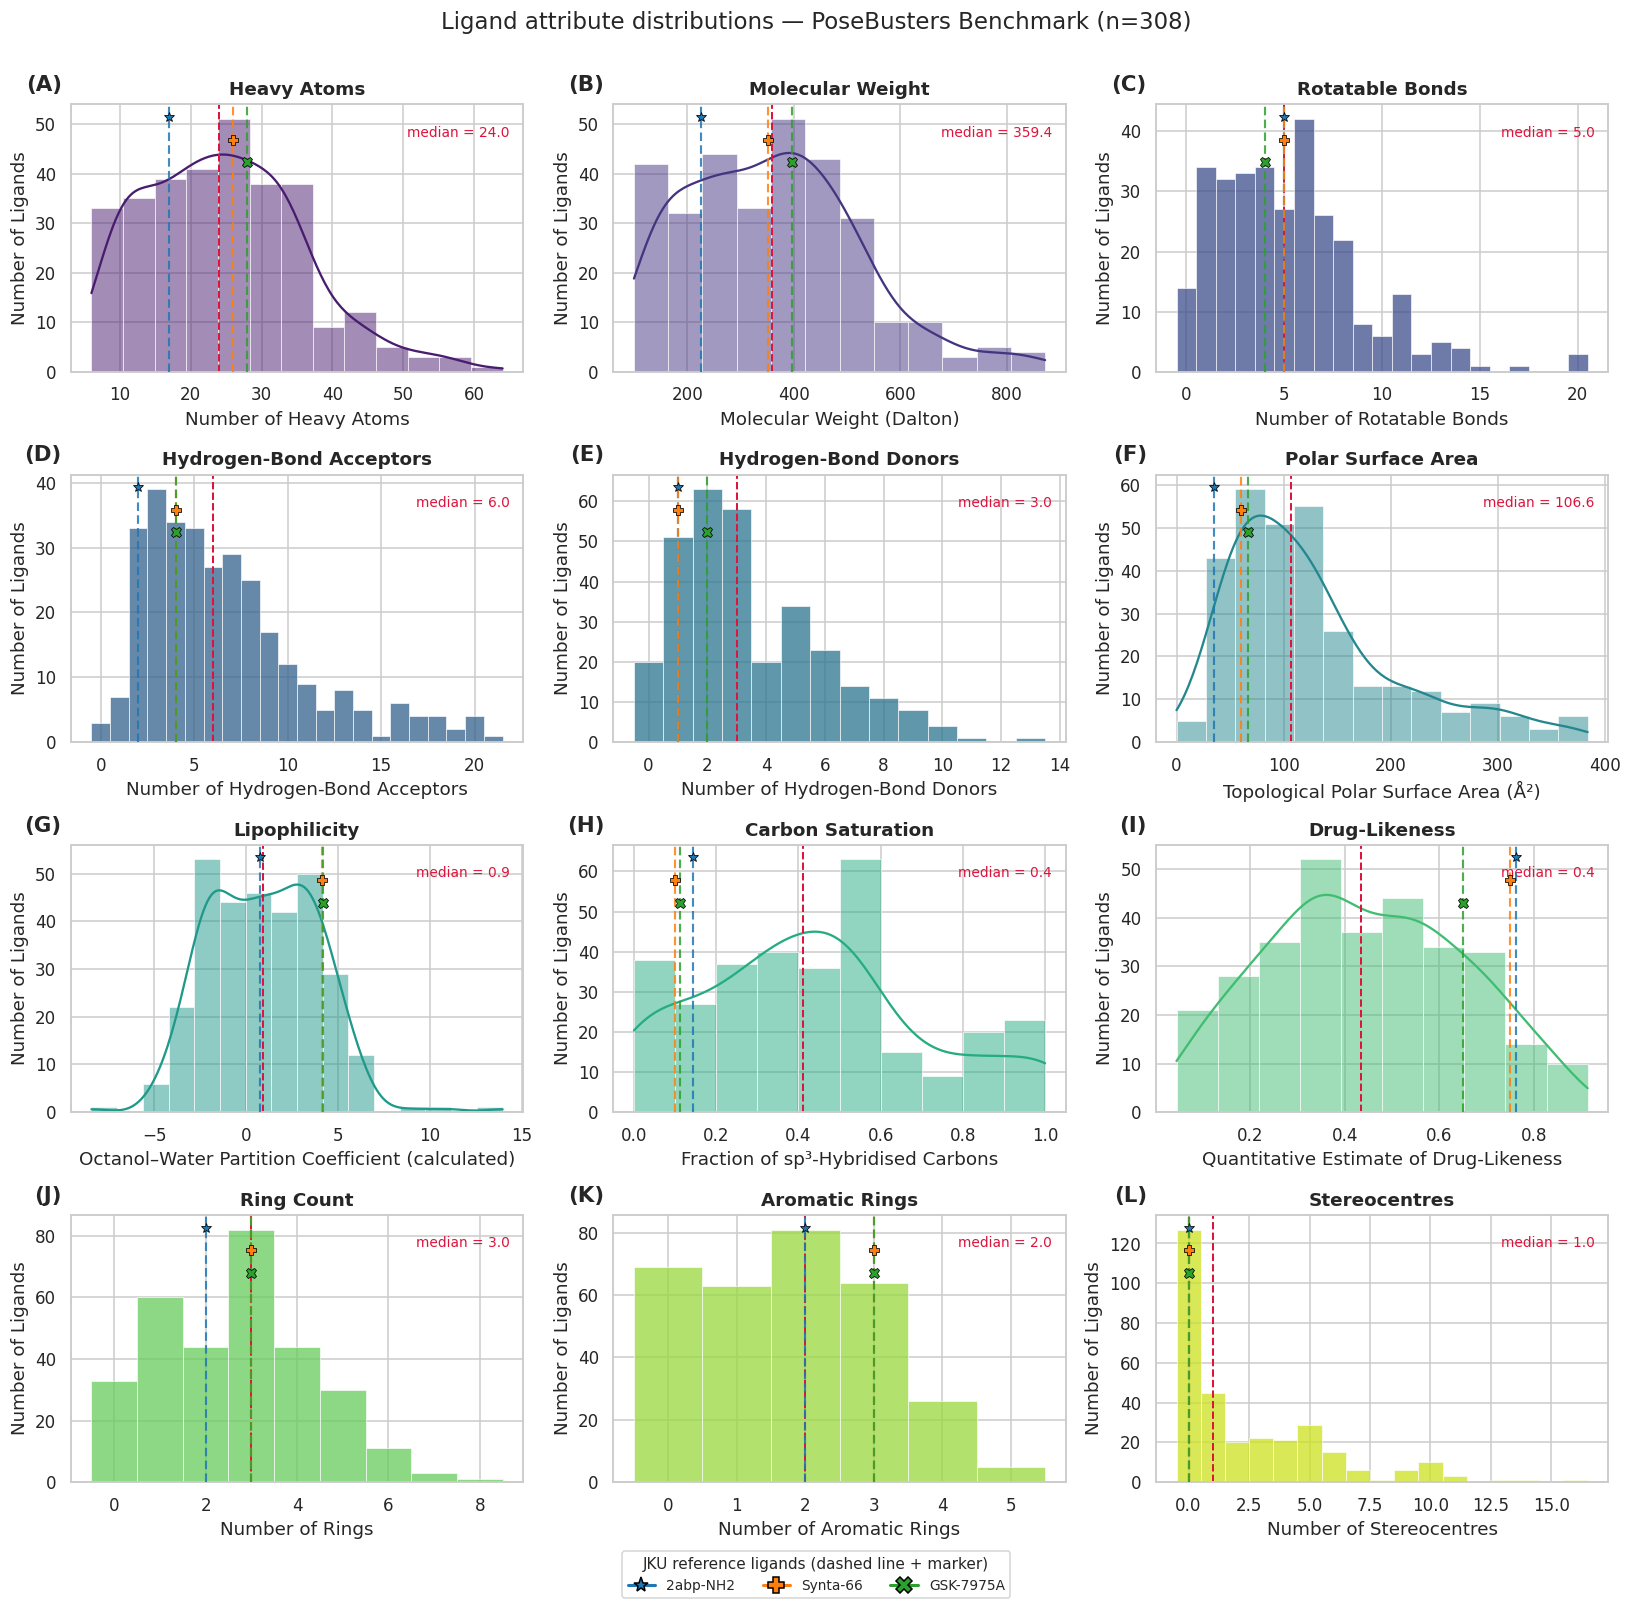

In [6]:
panel = ["heavy_atoms","mw","rot_bonds","hba","hbd","tpsa","logp","fsp3",
         "qed","n_rings","n_arom_rings","n_stereo"]
titles = ["Heavy Atoms","Molecular Weight","Rotatable Bonds",
          "Hydrogen-Bond Acceptors","Hydrogen-Bond Donors","Polar Surface Area",
          "Lipophilicity","Carbon Saturation","Drug-Likeness",
          "Ring Count","Aromatic Rings","Stereocentres"]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
for ax, col, ttl in zip(axes.ravel(), panel, titles):
    discrete = df[col].dropna().nunique() <= 25 and df[col].dtype != float
    sns.histplot(df[col].dropna(), ax=ax, color=sns.color_palette(PALETTE, 12)[panel.index(col)],
                 kde=not discrete, discrete=discrete, edgecolor="white", linewidth=.4)
    med = df[col].median()
    ax.axvline(med, ls="--", color="crimson", lw=1.3)
    overlay_jku_vlines(ax, col)
    ax.set_title(ttl); ax.set_xlabel(nice(col)); ax.set_ylabel("Number of Ligands")
    ax.text(0.97, 0.92, f"median = {med:.1f}", ha="right", va="top",
            transform=ax.transAxes, fontsize=9, color="crimson")
_label_panels(axes)
fig.suptitle(f"Ligand attribute distributions — PoseBusters Benchmark (n={len(df)})",
             fontsize=15, y=1.005)
fig.legend(handles=jku_legend_handles(), title="JKU reference ligands (dashed line + marker)",
           loc="lower center", ncol=len(jku_df), bbox_to_anchor=(0.5, -0.03),
           frameon=True, fontsize=9, title_fontsize=10)
savefig("01_ligand_univariate_distributions"); plt.show()

## 5 · Drug-likeness — Lipinski Ro5 & QED

The set is curated from the PDB and deliberately spans more than classic small-molecule
drug space: peptides, nucleotides, sugars and cofactors push many ligands outside the
Rule-of-Five box.

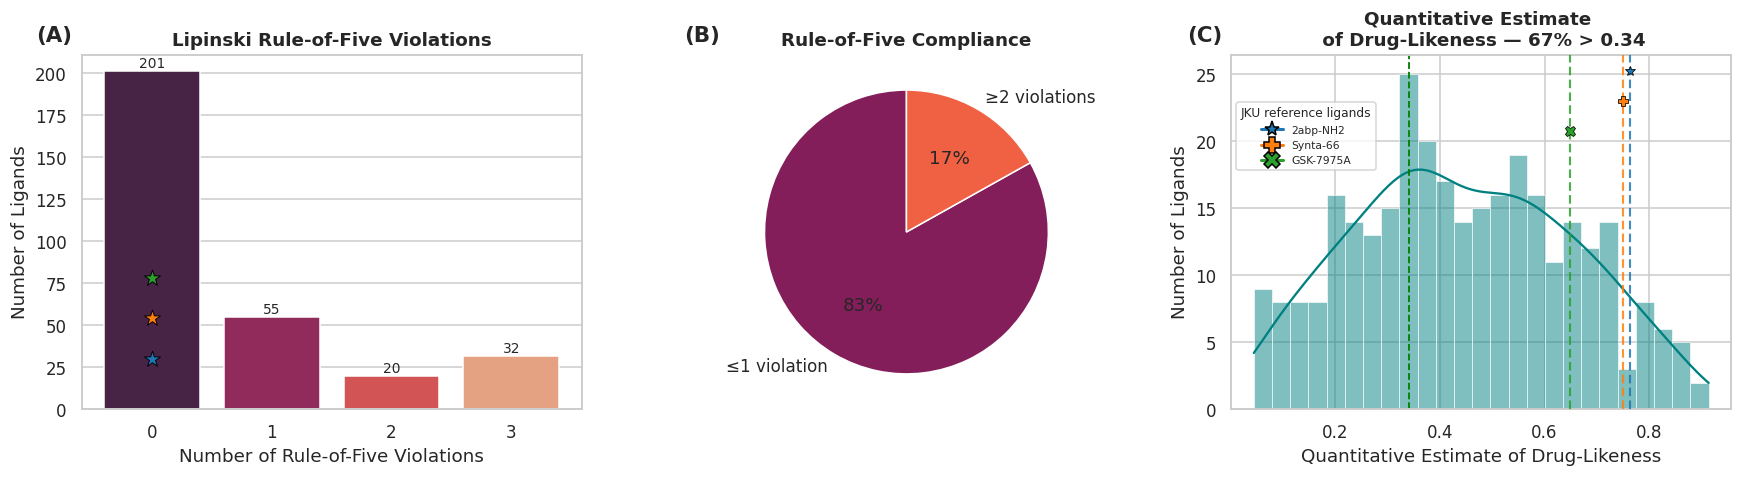

Strict Rule-of-Five (0 violations): 65%   | ≤1 violation: 83%


In [7]:
df["ro5_violations"] = ((df.mw>500).astype(int) + (df.logp>5).astype(int)
                        + (df.hbd>5).astype(int) + (df.hba>10).astype(int))
df["ro5_pass"] = df.ro5_violations <= 1     # standard "<=1 violation" criterion

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

vc = df.ro5_violations.value_counts().sort_index()
sns.barplot(x=vc.index, y=vc.values, ax=axes[0], palette="rocket")
for i, v in zip(vc.index, vc.values):
    axes[0].text(i, v+2, str(v), ha="center", fontsize=9)
axes[0].set(title="Lipinski Rule-of-Five Violations",
            xlabel="Number of Rule-of-Five Violations", ylabel="Number of Ligands")
# JKU ligands as stars at their violation count (stacked up the y-axis)
for k, (label, r) in enumerate(jku_df.iterrows()):
    axes[0].scatter(int(r.ro5_violations), vc.max()*(0.15 + 0.12*k),
                    color=JKU_COLORS[label], s=120, marker="*",
                    edgecolor="black", linewidth=.6, zorder=6)

pass_counts = df.ro5_pass.map({True:"≤1 violation", False:"≥2 violations"}).value_counts()
axes[1].pie(pass_counts.values, labels=pass_counts.index, autopct="%1.0f%%",
            colors=sns.color_palette("rocket", 2), startangle=90,
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Rule-of-Five Compliance")

sns.histplot(df.qed, bins=25, kde=True, ax=axes[2], color="teal",
             edgecolor="white", linewidth=.4)
for q, lbl, c in [(0.34,"attractive (>0.34)","green")]:
    axes[2].axvline(q, ls="--", color=c, lw=1.2)
overlay_jku_vlines(axes[2], "qed")
axes[2].set(title=f"Quantitative Estimate \n of Drug-Likeness — {(df.qed>0.34).mean()*100:.0f}% > 0.34",
            xlabel=nice("qed"), ylabel="Number of Ligands")
# anchor below the (C) panel label so the two don't overlap
axes[2].legend(handles=jku_legend_handles(), title="JKU reference ligands",
               fontsize=7, title_fontsize=8, loc="upper left",
               bbox_to_anchor=(0.0, 0.88))
_label_panels(axes)
savefig("02_druglikeness_ro5_qed"); plt.show()

print(f"Strict Rule-of-Five (0 violations): {(df.ro5_violations==0).mean()*100:.0f}%   "
      f"| ≤1 violation: {df.ro5_pass.mean()*100:.0f}%")

## 6 · Elemental & charge composition

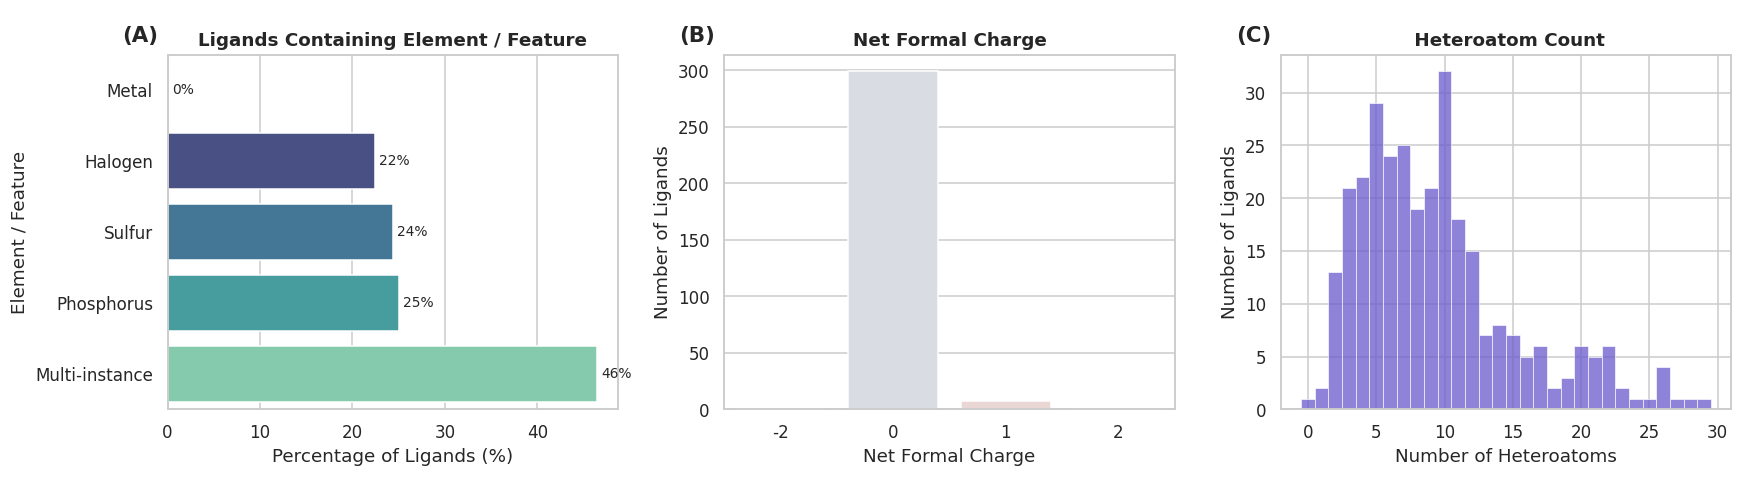

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

flags = {"Halogen": df.has_halogen, "Sulfur": df.has_sulfur,
         "Phosphorus": df.has_phosphorus, "Metal": df.has_metal,
         "Multi-instance": df.n_instances>1}
share = {k: v.mean()*100 for k, v in flags.items()}
s = pd.Series(share).sort_values()
sns.barplot(x=s.values, y=s.index, ax=axes[0], palette="mako")
for i, v in enumerate(s.values):
    axes[0].text(v+0.5, i, f"{v:.0f}%", va="center", fontsize=9)
axes[0].set(title="Ligands Containing Element / Feature",
            xlabel="Percentage of Ligands (%)", ylabel="Element / Feature")

cc = df.formal_charge.value_counts().sort_index()
sns.barplot(x=cc.index.astype(int), y=cc.values, ax=axes[1], palette="vlag")
axes[1].set(title="Net Formal Charge", xlabel=nice("formal_charge"),
            ylabel="Number of Ligands")

sns.histplot(df.n_heteroatoms, bins=range(0, df.n_heteroatoms.max()+2),
             ax=axes[2], color="slateblue", discrete=True, edgecolor="white", linewidth=.4)
axes[2].set(title="\n Heteroatom Count", xlabel="Number of Heteroatoms",
            ylabel="Number of Ligands")
_label_panels(axes)
savefig("03_elemental_charge_composition"); plt.show()

## 7 · Joint distributions & attribute mapping

How the attributes co-vary. The correlation heat-map summarises every pairwise
Pearson relationship; the scatter panel and pairplot map the most informative pairs.

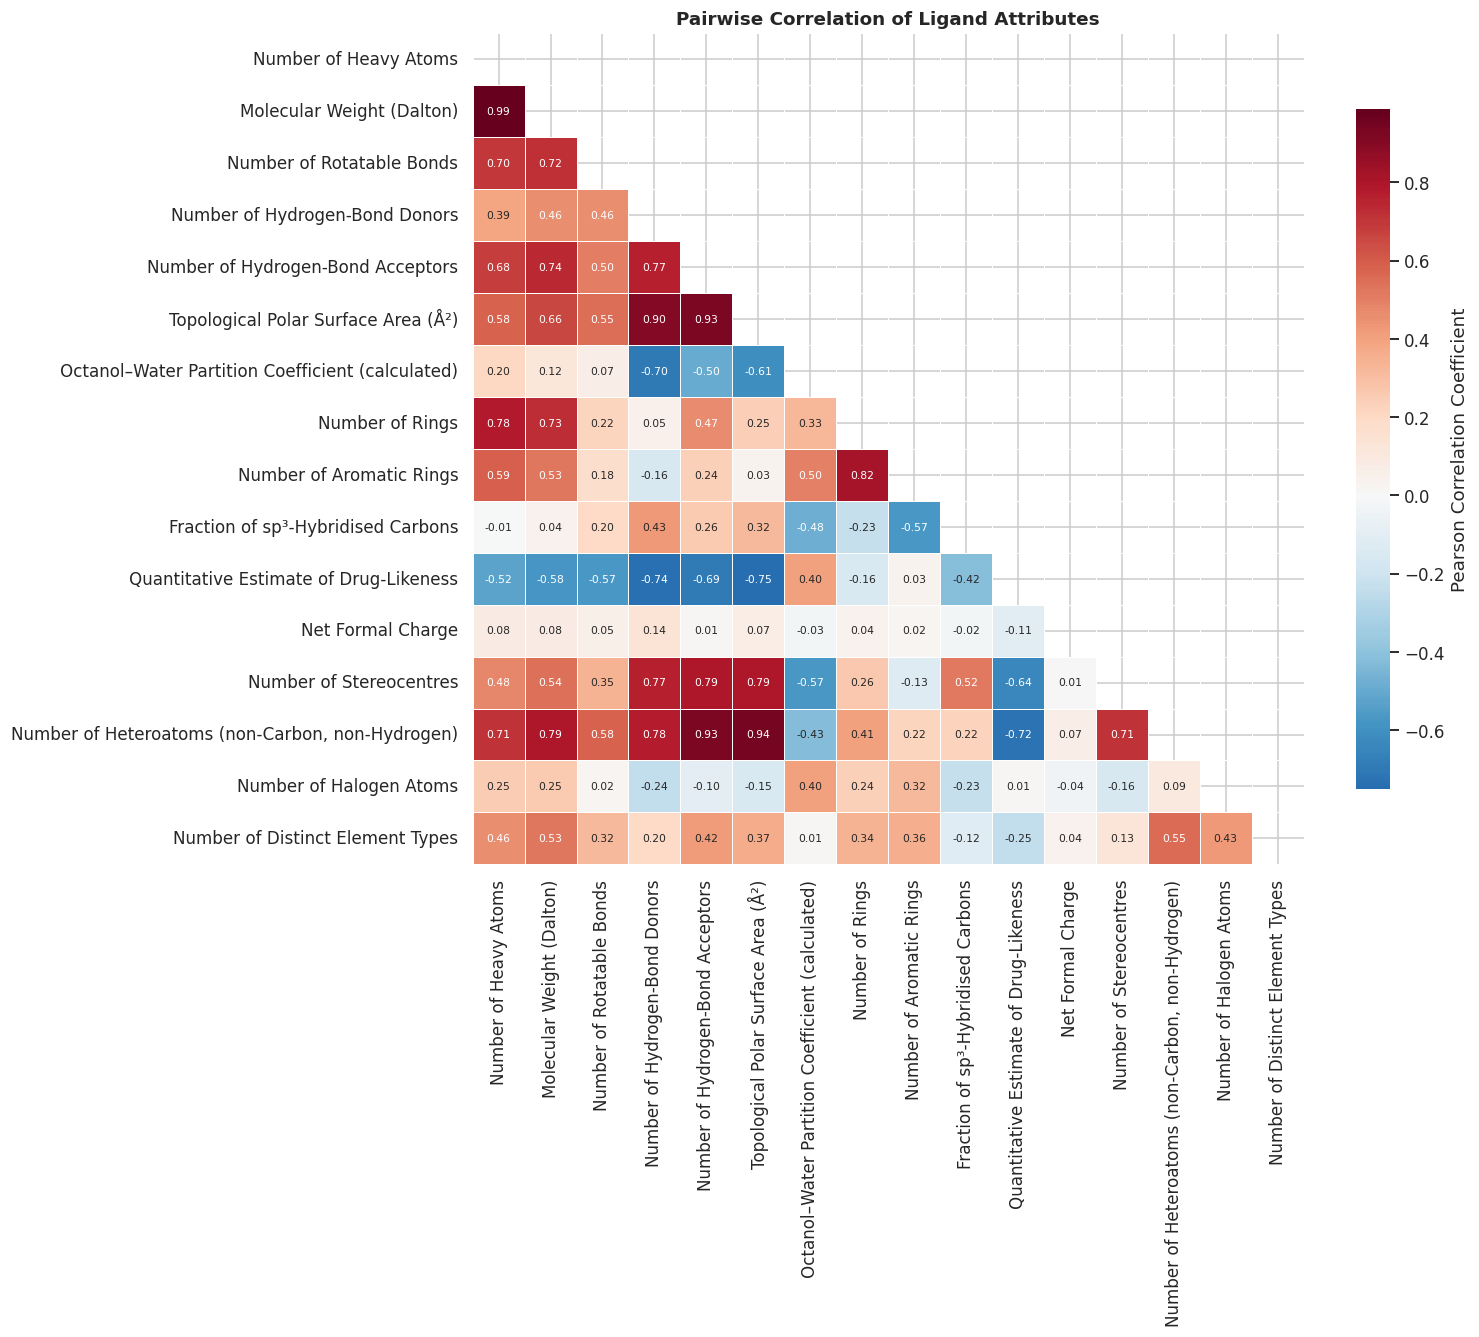

In [9]:
corr = df[LIG_NUM].corr().rename(index=NICE, columns=NICE)
mask = np.triu(np.ones_like(corr, dtype=bool))   # show only the lower triangle
plt.figure(figsize=(14, 12))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            square=True, linewidths=.5,
            cbar_kws=dict(shrink=.8, label="Pearson Correlation Coefficient"),
            annot_kws=dict(size=7))
plt.title("Pairwise Correlation of Ligand Attributes")
savefig("04_ligand_correlation_heatmap"); plt.show()

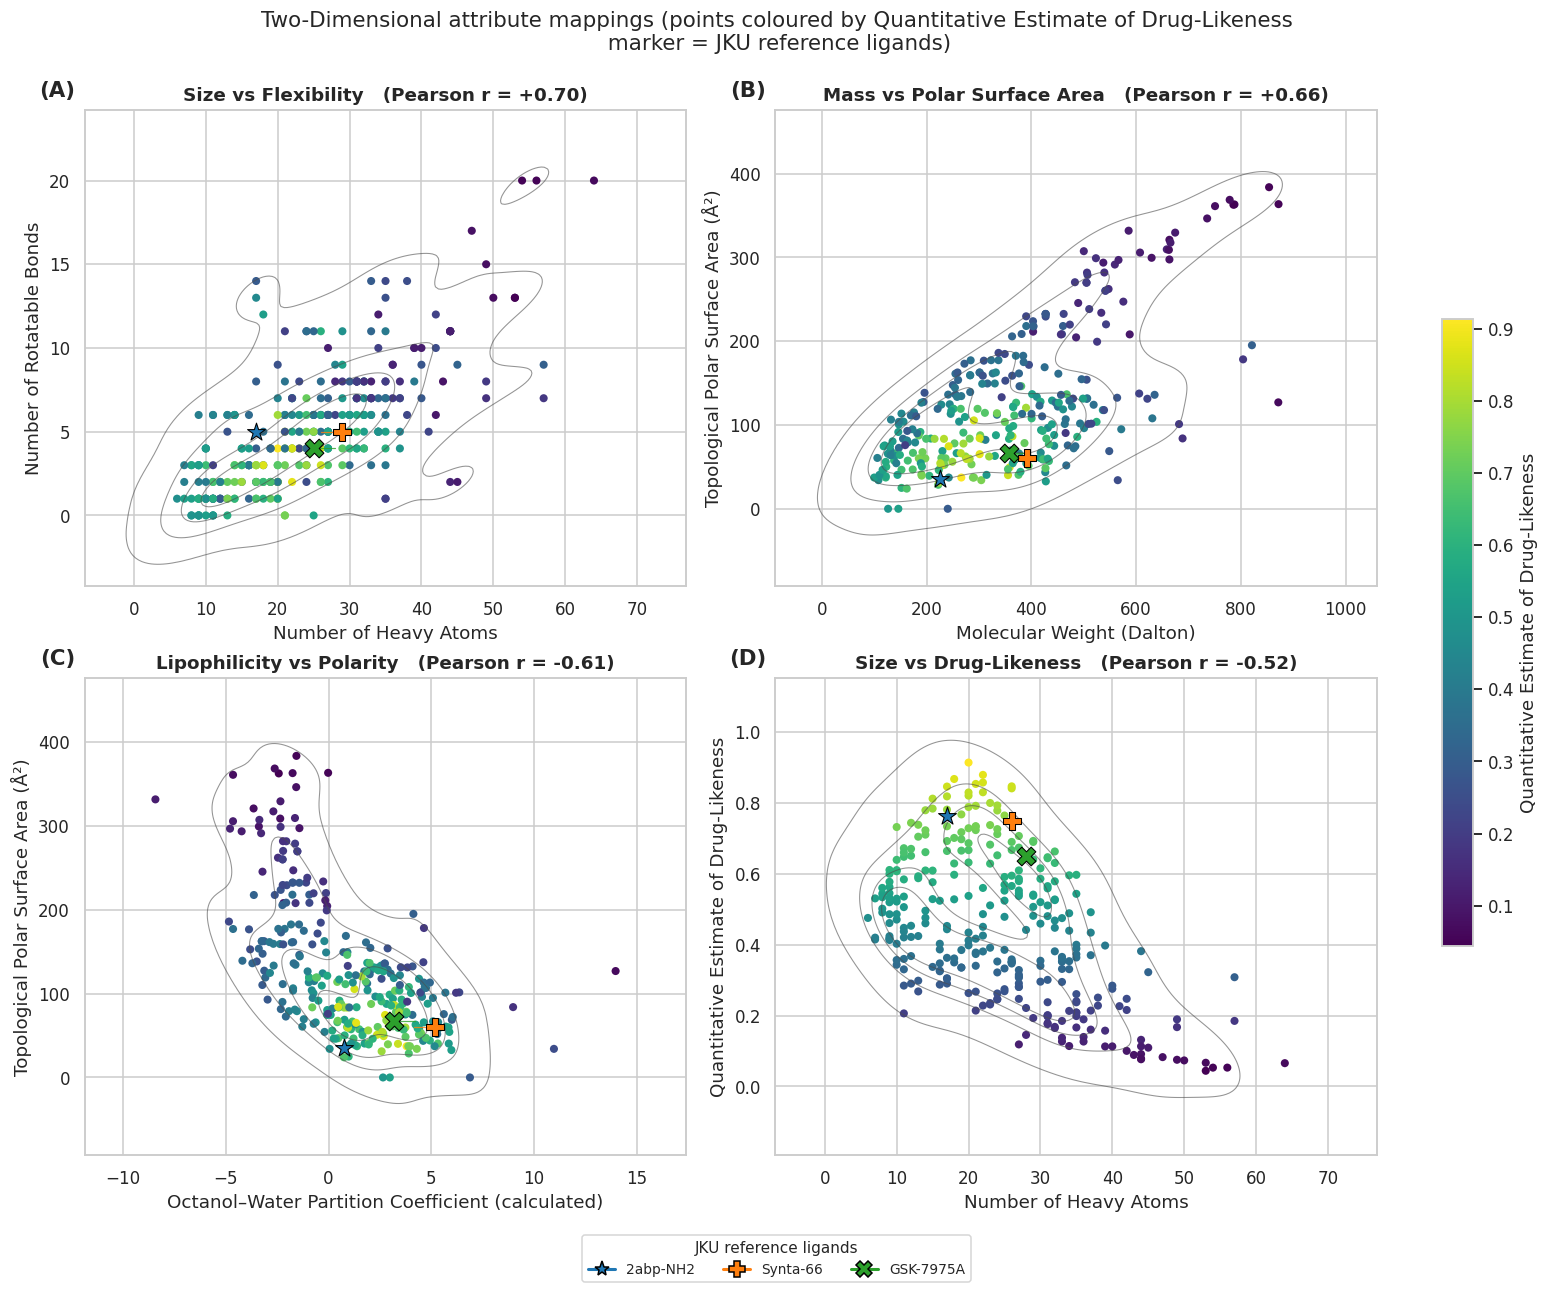

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)
maps = [("heavy_atoms","rot_bonds","Size vs Flexibility"),
        ("mw","tpsa","Mass vs Polar Surface Area"),
        ("logp","tpsa","Lipophilicity vs Polarity"),
        ("heavy_atoms","qed","Size vs Drug-Likeness")]
for ax, (x, y, ttl) in zip(axes.ravel(), maps):
    sns.scatterplot(data=df, x=x, y=y, hue="qed", palette="viridis",
                    s=28, edgecolor="none", ax=ax, legend=False)
    sns.kdeplot(data=df, x=x, y=y, ax=ax, levels=5, color="0.3", linewidths=.7, alpha=.6)
    overlay_jku_points(ax, x, y)
    r = df[[x, y]].corr().iloc[0, 1]
    ax.set_title(f"{ttl}   (Pearson r = {r:+.2f})")
    ax.set_xlabel(nice(x)); ax.set_ylabel(nice(y))
_label_panels(axes)
sm = plt.cm.ScalarMappable(cmap="viridis",
                           norm=plt.Normalize(df.qed.min(), df.qed.max()))
fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=.6,
             label="Quantitative Estimate of Drug-Likeness", location="right")
fig.legend(handles=jku_legend_handles(), title="JKU reference ligands",
           loc="lower center", ncol=len(jku_df), bbox_to_anchor=(0.5, -0.06),
           frameon=True, fontsize=9, title_fontsize=10)
fig.suptitle("Two-Dimensional attribute mappings "
             "(points coloured by Quantitative Estimate of Drug-Likeness\n "
             "marker = JKU reference ligands)\n", fontsize=14)
savefig("05_2d_attribute_mappings", tight=False); plt.show()

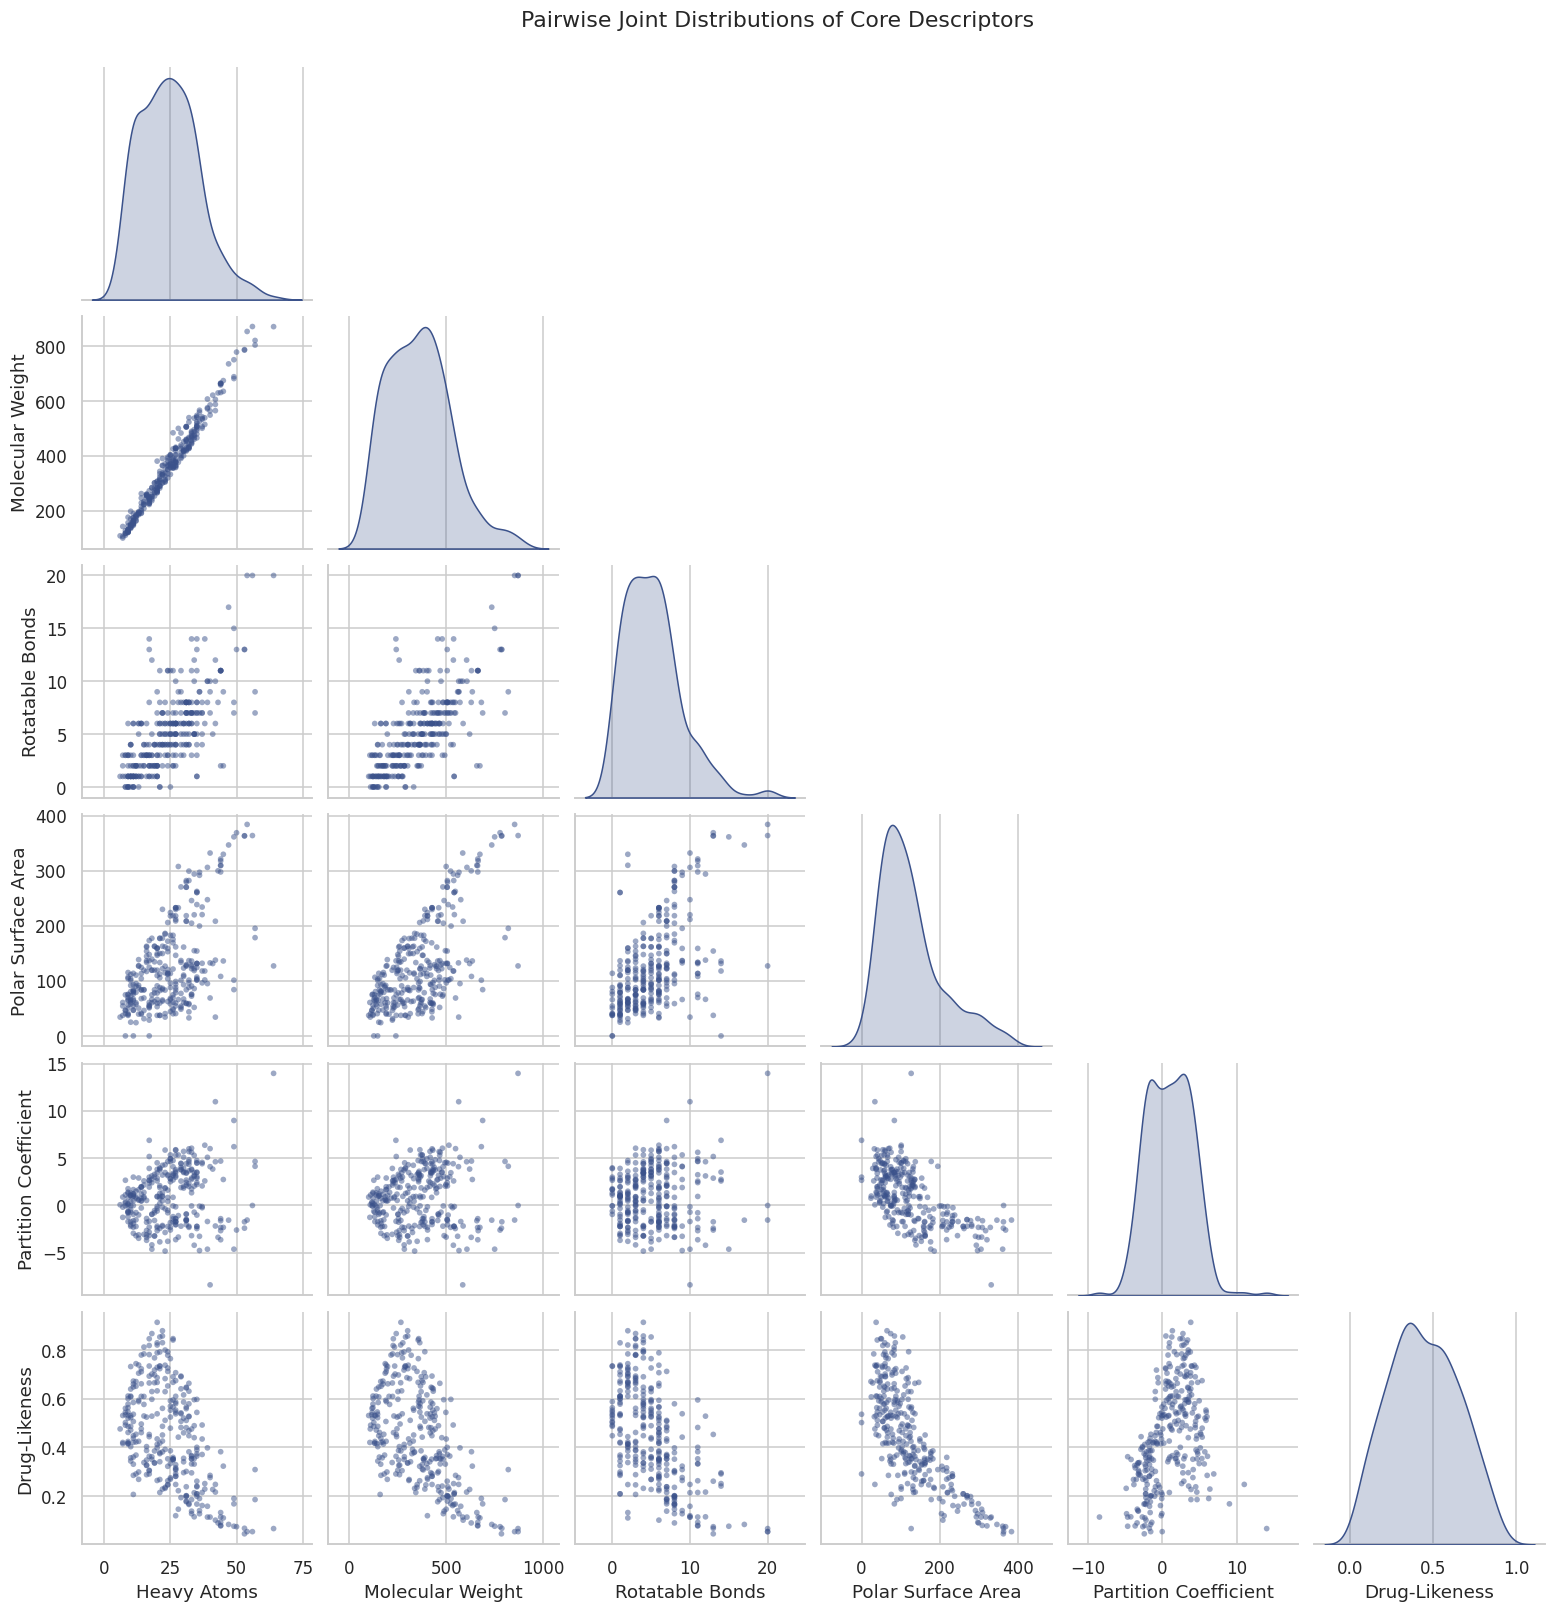

In [11]:
sub = ["heavy_atoms","mw","rot_bonds","tpsa","logp","qed"]
# Spell the descriptor names out (compact, no abbreviations) so the dense
# pairplot axes stay legible.
g = sns.pairplot(df[sub].rename(columns=SHORT), diag_kind="kde", corner=True, height=2.4,
                 plot_kws=dict(s=14, alpha=.5, edgecolor="none", color="#3b528b"),
                 diag_kws=dict(color="#3b528b", fill=True))
g.figure.suptitle("Pairwise Joint Distributions of Core Descriptors", y=1.02)
g.savefig(FIG_DIR / "06_pairplot_core_descriptors.png", bbox_inches="tight")
plt.show()

## 7b · Principal component analysis (PCA) of ligand descriptors

The Sec 7 heat-map showed the physicochemical descriptors are strongly **collinear**
(size terms move together; polarity terms move together). PCA exploits that redundancy:
it rotates the 16 standardised descriptors into orthogonal **principal components (PCs)**
ordered by the variance they capture, so a handful of axes summarise most of chemical space.

**Method & why these choices**
- *Inputs:* only the continuous / count descriptors (`LIG_NUM`). Binary element flags
  (`has_halogen` …) are excluded — PCA assumes linear variance, not 0/1 categories.
- *Standardisation:* each descriptor is z-scored (mean 0, sd 1) **before** PCA, otherwise
  `mw` (hundreds) would dominate `fsp3`/`qed` (0–1) purely through scale.
- *Receptor descriptors are deliberately left out* — only 4 features, two of them
  (`n_residues`, `prot_heavy_atoms`) near-duplicates, so PCA adds nothing there.

Each PC is a **weighted combination of all descriptors**; the weights are the *loadings*.
Within one PC, descriptors with **same-sign** large loadings co-vary *positively* along that
axis, while **opposite-sign** loadings are *anti-correlated*. The benchmark forms the cloud;
the 5 JKU ligands are projected with the same scaler/rotation and overlaid.

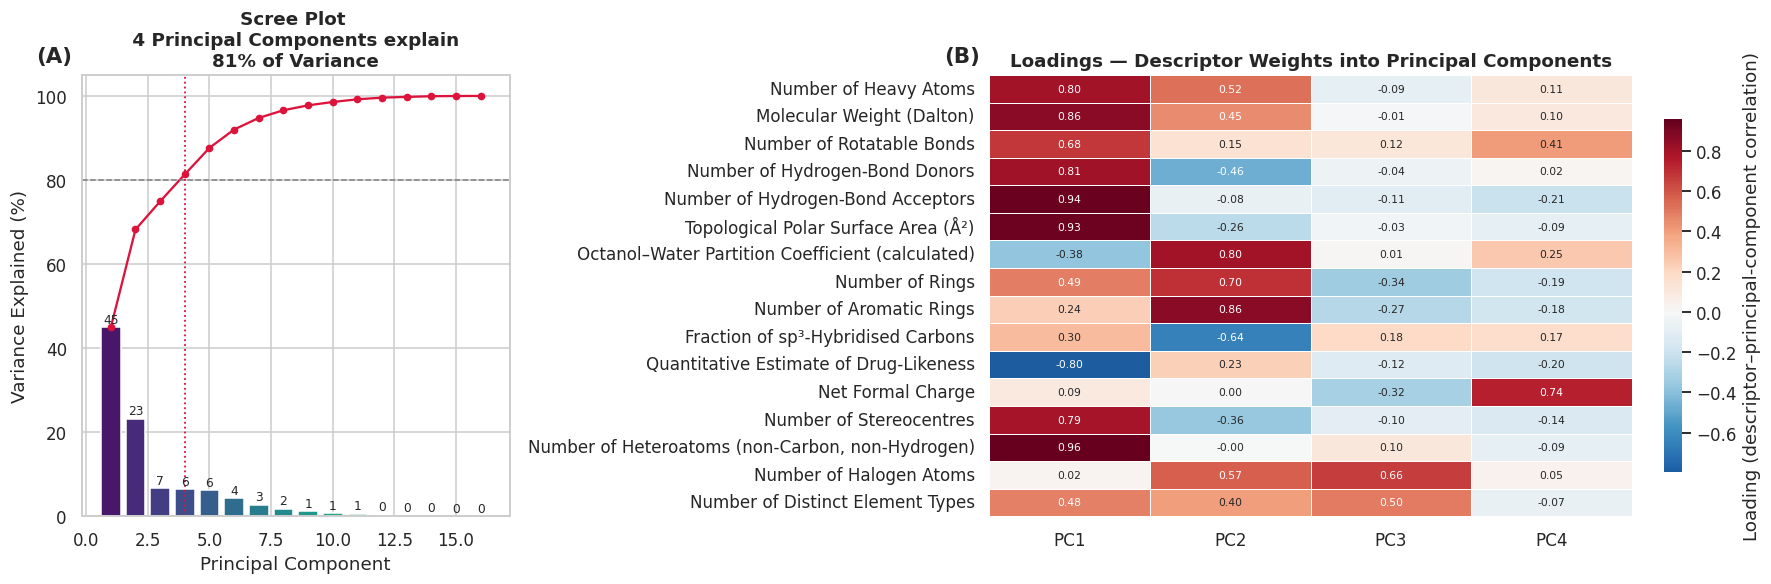

PCA on 16 standardised ligand descriptors  (n=308 complexes)
PC1  —   45.0% variance (cumulative 45%)
   strong + loadings : n_heteroatoms (+0.96), hba (+0.94), tpsa (+0.93), mw (+0.86), hbd (+0.81), heavy_atoms (+0.80), n_stereo (+0.79), rot_bonds (+0.68), n_rings (+0.49), n_element_types (+0.48), fsp3 (+0.30)
   strong − loadings : qed (-0.80), logp (-0.38)
   dominant driver   : n_heteroatoms  (loading +0.96)
------------------------------------------------------------------------------
PC2  —   23.3% variance (cumulative 68%)
   strong + loadings : n_arom_rings (+0.86), logp (+0.80), n_rings (+0.70), n_halogens (+0.57), heavy_atoms (+0.52), mw (+0.45), n_element_types (+0.40)
   strong − loadings : fsp3 (-0.64), hbd (-0.46), n_stereo (-0.36)
   dominant driver   : n_arom_rings  (loading +0.86)
------------------------------------------------------------------------------
PC3  —    6.7% variance (cumulative 75%)
   strong + loadings : n_halogens (+0.66), n_element_types (+0.50)
   s

,PC1,PC2,PC3,PC4
heavy_atoms,0.804,0.521,-0.085,0.106
mw,0.861,0.454,-0.010,0.099
rot_bonds,0.675,0.149,0.120,0.408
hbd,0.811,-0.463,-0.045,0.017
hba,0.943,-0.075,-0.109,-0.214
tpsa,0.934,-0.256,-0.030,-0.087
logp,-0.377,0.804,0.007,0.253
n_rings,0.487,0.698,-0.339,-0.192
n_arom_rings,0.238,0.858,-0.273,-0.179
fsp3,0.305,-0.645,0.185,0.173


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# continuous / count descriptors only (drop binary flags)
PCA_FEATURES = LIG_NUM
X = df[PCA_FEATURES].dropna()
scaler = StandardScaler().fit(X)
Xz = scaler.transform(X)

pca = PCA().fit(Xz)
scores = pca.transform(Xz)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
n_keep = int(np.searchsorted(cum, 0.80) + 1)   # PCs needed for >=80% variance
pc_labels = [f"PC{i+1}" for i in range(len(evr))]
# spelled-out principal-component names for the figures (no "PC" abbreviation)
PC_FULL = {f"PC{i+1}": f"Principal Component {i+1}" for i in range(len(evr))}

# loadings = eigenvectors scaled by sqrt(eigenvalue) -> correlation of feature with PC
loadings = pd.DataFrame(
    (pca.components_.T * np.sqrt(pca.explained_variance_)),
    index=PCA_FEATURES, columns=pc_labels)

# ---- scree + loadings heat-map -------------------------------------------
# constrained_layout (not tight_layout) so the seaborn colorbar + its long
# label and the bold titles are never clipped.
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2),
                         gridspec_kw=dict(width_ratios=[1, 1.5]),
                         constrained_layout=True)
axes[0].bar(range(1, len(evr)+1), evr*100, color=sns.color_palette('viridis', len(evr)))
axes[0].plot(range(1, len(evr)+1), cum*100, '-o', color='crimson', lw=1.5, ms=4)
axes[0].axhline(80, ls='--', color='grey', lw=1)
axes[0].axvline(n_keep, ls=':', color='crimson', lw=1.2)
axes[0].set(title=f'Scree Plot \n {n_keep} Principal Components explain \n{cum[n_keep-1]*100:.0f}% of Variance',
            xlabel='Principal Component', ylabel='Variance Explained (%)')
for i,(e,c) in enumerate(zip(evr, cum), 1):
    axes[0].text(i, e*100+1, f'{e*100:.0f}', ha='center', fontsize=8)

show = max(n_keep, 4)
loadings_show = loadings.iloc[:, :show].rename(index=NICE)
sns.heatmap(loadings_show, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=.4,
            cbar_kws=dict(shrink=.8, label='Loading (descriptor–principal-component correlation)'),
            ax=axes[1], annot_kws=dict(size=7))
axes[1].set_title('Loadings — Descriptor Weights into Principal Components')
_label_panels(axes)
savefig('09_pca_scree_loadings', tight=False); plt.show()

# ---- detailed, data-driven interpretation of each retained PC -------------
print('PCA on', len(PCA_FEATURES), 'standardised ligand descriptors  '
      f'(n={len(X)} complexes)')
print('='*78)
for j in range(show):
    pc = pc_labels[j]
    col = loadings[pc].sort_values(key=np.abs, ascending=False)
    pos = [f'{f} (+{v:.2f})' for f, v in col.items() if v > 0.30]
    neg = [f'{f} ({v:.2f})'  for f, v in col.items() if v < -0.30]
    print(f'{pc}  —  {evr[j]*100:5.1f}% variance (cumulative {cum[j]*100:.0f}%)')
    print(f'   strong + loadings : {", ".join(pos) if pos else "—"}')
    print(f'   strong − loadings : {", ".join(neg) if neg else "—"}')
    top = col.index[0]
    print(f'   dominant driver   : {top}  (loading {col.iloc[0]:+.2f})')
    print('-'*78)
print('Reading: within a PC, same-sign descriptors co-vary positively; opposite')
print('signs are anti-correlated along that axis. PC signs themselves are arbitrary.')
loadings.iloc[:, :show].round(3)

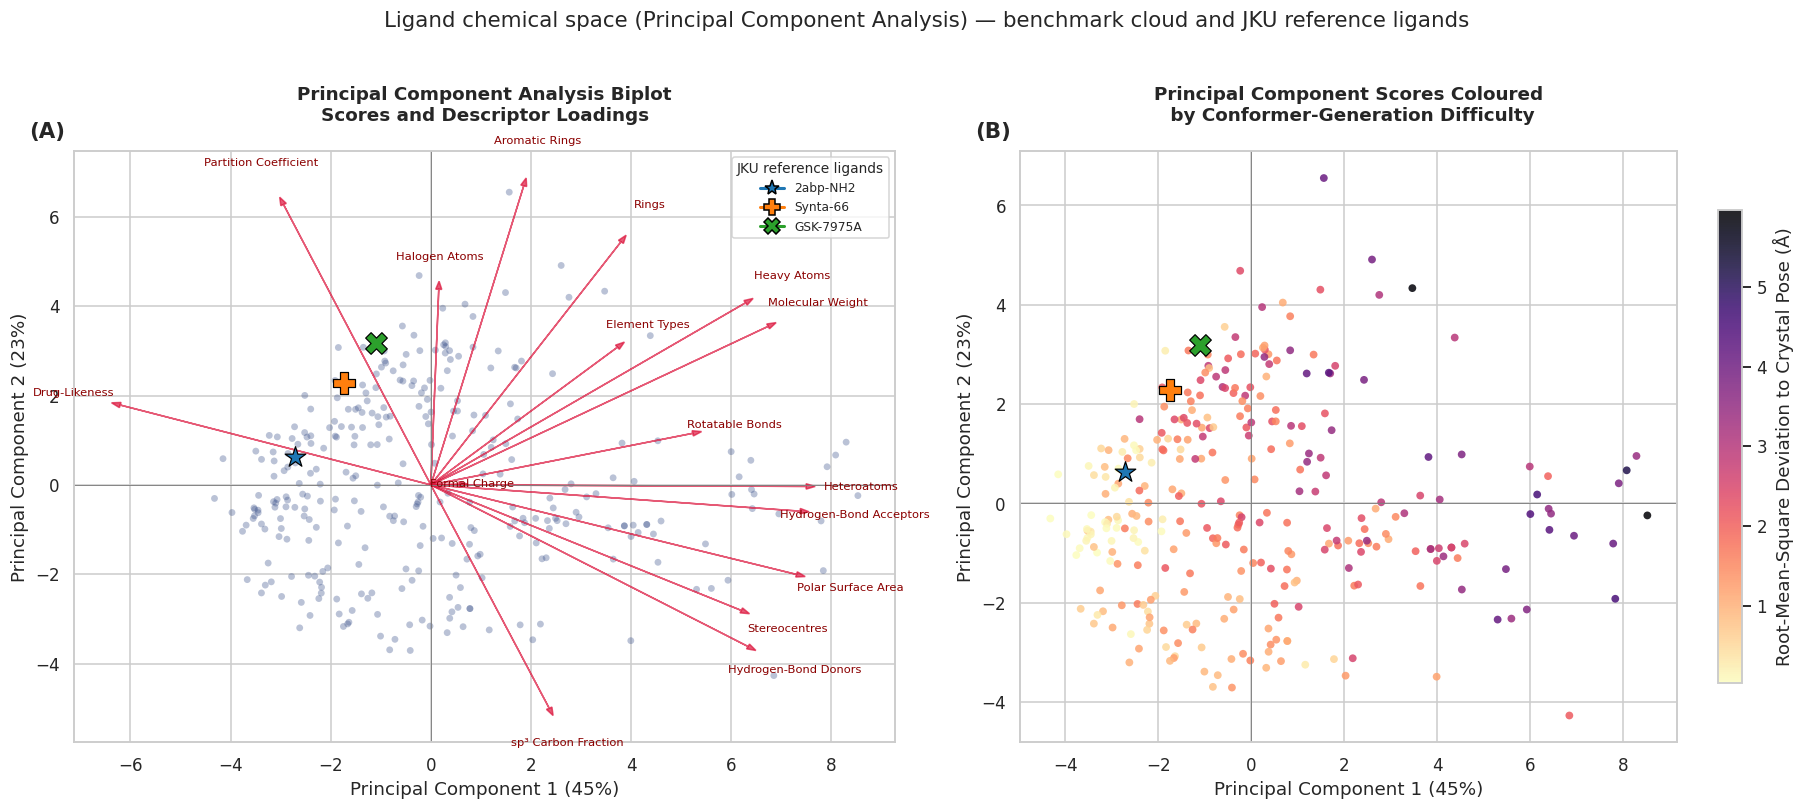

JKU ligand coordinates in PC space:


,PC1,PC2,PC3,PC4
label,,,,
2abp-NH2,-2.71,0.63,-0.04,-0.25
Synta-66,-1.74,2.28,0.00,-0.20
GSK-7975A,-1.10,3.18,2.19,-0.07


In [13]:
# project the JKU reference ligands into the same PC space
jku_scores = pca.transform(scaler.transform(jku_df[PCA_FEATURES]))

fig, axes = plt.subplots(1, 2, figsize=(17, 7.2))

# ---- (a) biplot: scores (PC1 vs PC2) + loading vectors --------------------
ax = axes[0]
ax.scatter(scores[:, 0], scores[:, 1], s=20, alpha=.35, color='#3b528b',
           edgecolor='none', label='benchmark')
arrow_scale = np.abs(scores[:, :2]).max() / np.abs(loadings.iloc[:, :2].values).max() * 0.9
for feat in PCA_FEATURES:
    lx, ly = loadings.loc[feat, 'PC1'], loadings.loc[feat, 'PC2']
    ax.arrow(0, 0, lx*arrow_scale, ly*arrow_scale, color='crimson',
             alpha=.7, head_width=.12, length_includes_head=True, lw=1)
    ax.text(lx*arrow_scale*1.12, ly*arrow_scale*1.12, short(feat), color='darkred',
            fontsize=7.5, ha='center', va='center')
for k, label in enumerate(jku_df.index):
    ax.scatter(jku_scores[k, 0], jku_scores[k, 1], color=JKU_COLORS[label],
               marker=JKU_MARKERS[label], s=200, edgecolor='black',
               linewidth=.8, zorder=6)
ax.axhline(0, color='grey', lw=.6); ax.axvline(0, color='grey', lw=.6)
ax.set(title='Principal Component Analysis Biplot\nScores and Descriptor Loadings\n',
       xlabel=f'Principal Component 1 ({evr[0]*100:.0f}%)',
       ylabel=f'Principal Component 2 ({evr[1]*100:.0f}%)')
ax.legend(handles=jku_legend_handles(), title='JKU reference ligands', fontsize=8,
          title_fontsize=9, loc='best')

# ---- (b) score plot coloured by conformer difficulty (startconf_rmsd) -----
ax = axes[1]
rmsd_vals = df.loc[X.index, 'startconf_rmsd']
sc = ax.scatter(scores[:, 0], scores[:, 1], c=rmsd_vals, cmap='magma_r',
                s=26, edgecolor='none', alpha=.85)
for k, label in enumerate(jku_df.index):
    ax.scatter(jku_scores[k, 0], jku_scores[k, 1], color=JKU_COLORS[label],
               marker=JKU_MARKERS[label], s=200, edgecolor='black',
               linewidth=.8, zorder=6)
fig.colorbar(sc, ax=ax, shrink=.8, label='Root-Mean-Square Deviation to Crystal Pose (Å)')
ax.axhline(0, color='grey', lw=.6); ax.axvline(0, color='grey', lw=.6)
ax.set(title='Principal Component Scores Coloured\n by Conformer-Generation Difficulty\n',
       xlabel=f'Principal Component 1 ({evr[0]*100:.0f}%)',
       ylabel=f'Principal Component 2 ({evr[1]*100:.0f}%)')

_label_panels(axes)
fig.suptitle('Ligand chemical space (Principal Component Analysis) — '
             'benchmark cloud and JKU reference ligands',
             fontsize=14, y=1.02)
savefig('10_pca_biplot'); plt.show()

# where do the JKU ligands sit on each PC?
jku_pc = pd.DataFrame(jku_scores[:, :show], index=jku_df.index,
                      columns=pc_labels[:show]).round(2)
print('JKU ligand coordinates in PC space:')
jku_pc

### Interpreting the PCA — what the components mean

**Dimensionality.** The 16 standardised ligand descriptors collapse onto a few axes:
**PC1 ≈ 45 %** and **PC2 ≈ 23 %** of the variance (≈ **68 % in 2-D**), and **4 PCs reach ~81 %**.
So most of the chemical diversity in this set is governed by just two underlying factors,
which is exactly why the Sec 7 descriptors looked so correlated.

**PC1 — molecular size & polarity *vs* drug-likeness (the dominant axis).**
All the "bigger / more polar / more H-bonding" descriptors load **together and positively**:
`n_heteroatoms` (+0.96), `hba` (+0.94), `tpsa` (+0.93), `mw` (+0.86), `hbd` (+0.81),
`heavy_atoms` (+0.80), `n_stereo` (+0.79), `rot_bonds` (+0.68). Opposing them with a strong
**negative** loading is `qed` (−0.80) (with `logp` −0.38). *Reading:* moving right along PC1
means larger, more polar, more flexible, more stereochemically complex molecules — and these
are systematically **less drug-like** (QED drops). PC1 is essentially a "size/complexity ⇄
lead-likeness" trade-off and is the single most informative axis of the benchmark.

**PC2 — aromatic / lipophilic *vs* saturated, H-bond-donating character.**
Positive: `n_arom_rings` (+0.86), `logp` (+0.80), `n_rings` (+0.70), `n_halogens` (+0.57).
Negative: `fsp3` (−0.64), `hbd` (−0.46), `n_stereo` (−0.36). *Reading:* at a *given* size (PC1),
PC2 separates **flat, lipophilic, aromatic, halogenated** scaffolds (top) from **saturated, sp³-rich,
H-bond-donating** ones (bottom). Because these descriptor groups have opposite signs, they are
**anti-correlated** along this axis — a molecule is pulled one way or the other, rarely both.

**PC3 (~7 %) and PC4 (~6 %) — minor, specific chemistry.** PC3 is mostly **halogenation /
element diversity** (`n_halogens` +0.66, `n_element_types` +0.50); PC4 is essentially the
**formal-charge** axis (`formal_charge` +0.74). These capture niche features that are independent
of the size/polarity backbone.

**How the descriptors influence each other.** The biplot arrows make the structure explicit:
arrows pointing the **same direction** (e.g. `mw`, `tpsa`, `hba`, `n_heteroatoms`) are strongly
**positively correlated**; arrows pointing **opposite** ways (`qed` vs the size cluster; `fsp3`
vs `n_arom_rings`/`logp`) are **anti-correlated**; arrows at **right angles** (e.g. the charge
axis vs the size axis) are roughly **independent**. Longer arrows = better represented in the PC1–PC2 plane.

**Conformer-generation difficulty.** In the right-hand score plot, `startconf_rmsd` rises toward
**+PC1** — larger, more flexible, more polar ligands are harder to reproduce from a single
ETKDGv3+UFF conformer, consistent with the Sec 9 regressions. PC2 has little effect on difficulty,
so *size/flexibility* (PC1), not *aromatic/lipophilic balance* (PC2), is the dominant driver of search burden.

**Where the JKU reference ligands fall.** All currently-loaded JKU ligands sit at **negative PC1**
(smaller and less polar than the typical benchmark complex) and **positive PC2** (aromatic /
lipophilic character) — `GSK7975A (deprot)` being the most extreme on PC2/PC3. They therefore
occupy a compact, lead-like, comparatively **easy-to-conformer** corner of the benchmark's chemical
space rather than its large/polar/high-RMSD tail.

> *Caveat:* PC sign is arbitrary (a component and its negation are equivalent), so interpret
> *relative* position along an axis, not the absolute sign. Loadings here are eigenvector ×
> √eigenvalue, i.e. the **correlation** of each descriptor with the PC, so |loading| ≤ 1.

## 8 · Receptor / protein profile

Receptor size, oligomeric state and bound cofactors. Residue counts are read from the
ATOM records (one entry per chain·resseq); chains and HETATM components from columns 22
and 18–20. Note the long tail of very large multi-chain assemblies.

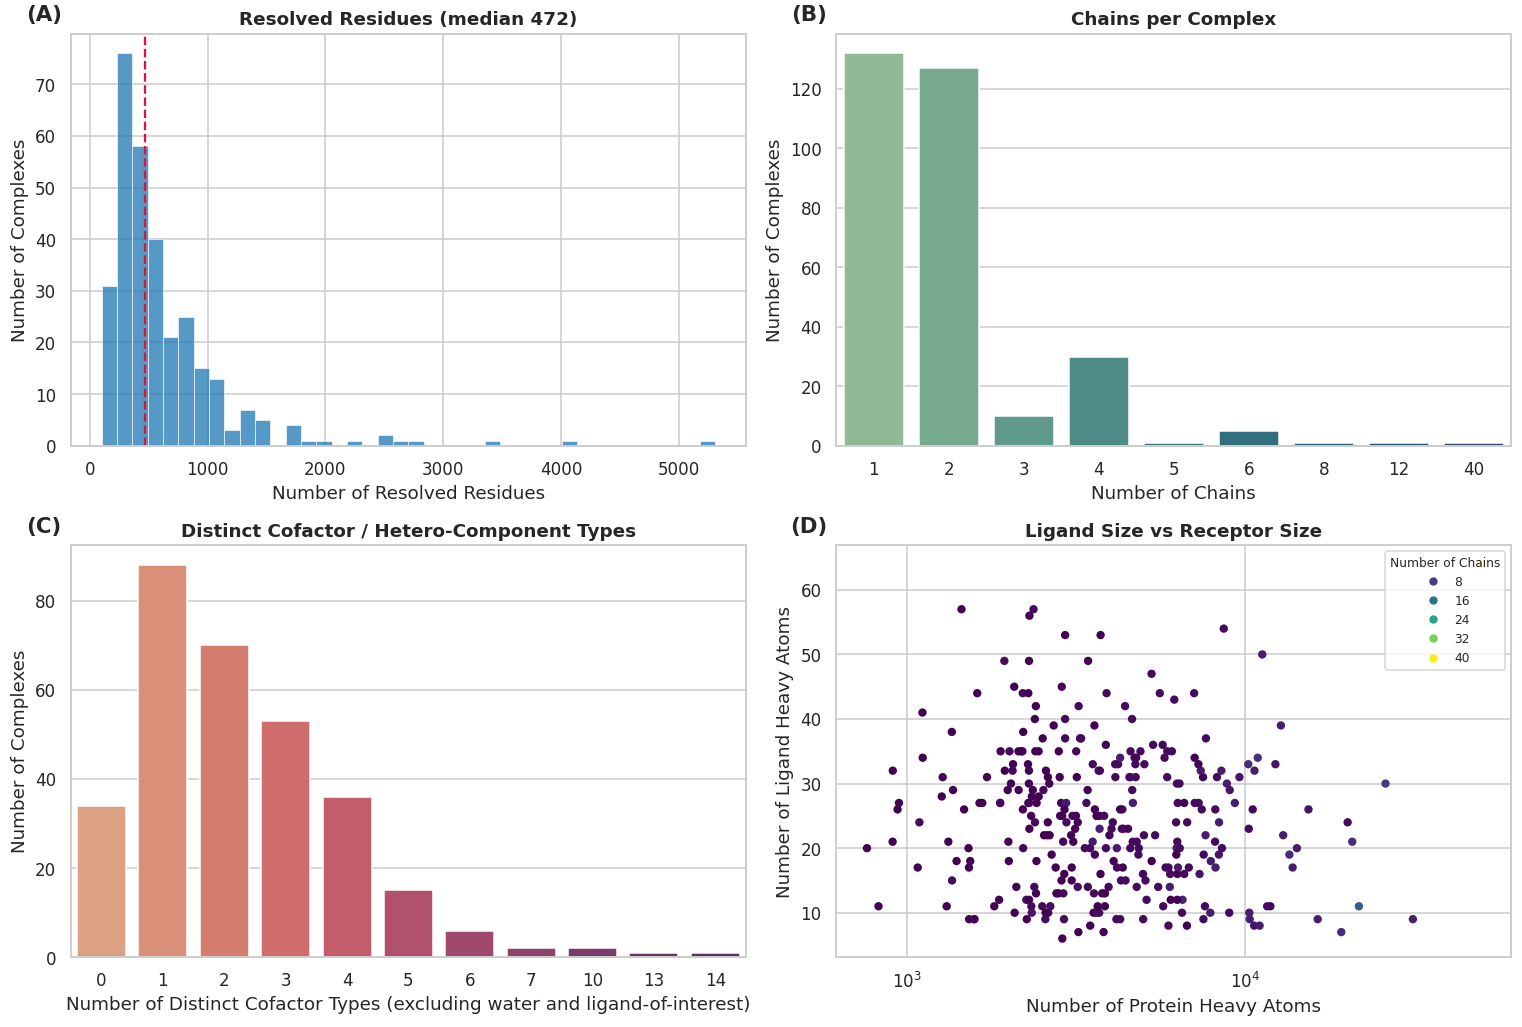

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))

sns.histplot(df.n_residues, bins=40, ax=axes[0,0], color="#1f77b4",
             edgecolor="white", linewidth=.4)
axes[0,0].axvline(df.n_residues.median(), ls="--", color="crimson")
axes[0,0].set(title=f"Resolved Residues (median {df.n_residues.median():.0f})",
              xlabel=nice("n_residues"), ylabel="Number of Complexes")

ch = df.n_chains.value_counts().sort_index()
sns.barplot(x=ch.index.astype(int), y=ch.values, ax=axes[0,1], palette="crest")
axes[0,1].set(title="Chains per Complex", xlabel=nice("n_chains"),
              ylabel="Number of Complexes")

cof = df.n_cofactor_types.value_counts().sort_index()
sns.barplot(x=cof.index.astype(int), y=cof.values, ax=axes[1,0], palette="flare")
axes[1,0].set(title="Distinct Cofactor / Hetero-Component Types",
              xlabel="Number of Distinct Cofactor Types (excluding water and ligand-of-interest)",
              ylabel="Number of Complexes")

sns.scatterplot(data=df, x="prot_heavy_atoms", y="heavy_atoms", ax=axes[1,1],
                hue="n_chains", palette="viridis", s=30, edgecolor="none")
axes[1,1].set(title="Ligand Size vs Receptor Size",
              xlabel=nice("prot_heavy_atoms"),
              ylabel="Number of Ligand Heavy Atoms")
axes[1,1].set_xscale("log")
axes[1,1].legend(title="Number of Chains", fontsize=8, title_fontsize=8, loc="upper right")
_label_panels(axes)
savefig("07_receptor_profile"); plt.show()

## 9 · Conformer-generation difficulty (start-conf → crystal RMSD)

The provided `*_ligand_start_conf.sdf` is a single ETKDGv3+UFF conformer. Its
symmetry-corrected RMSD to the crystal pose is a lower-bound proxy for how far a docking
engine must travel — and grows with molecular size and flexibility.

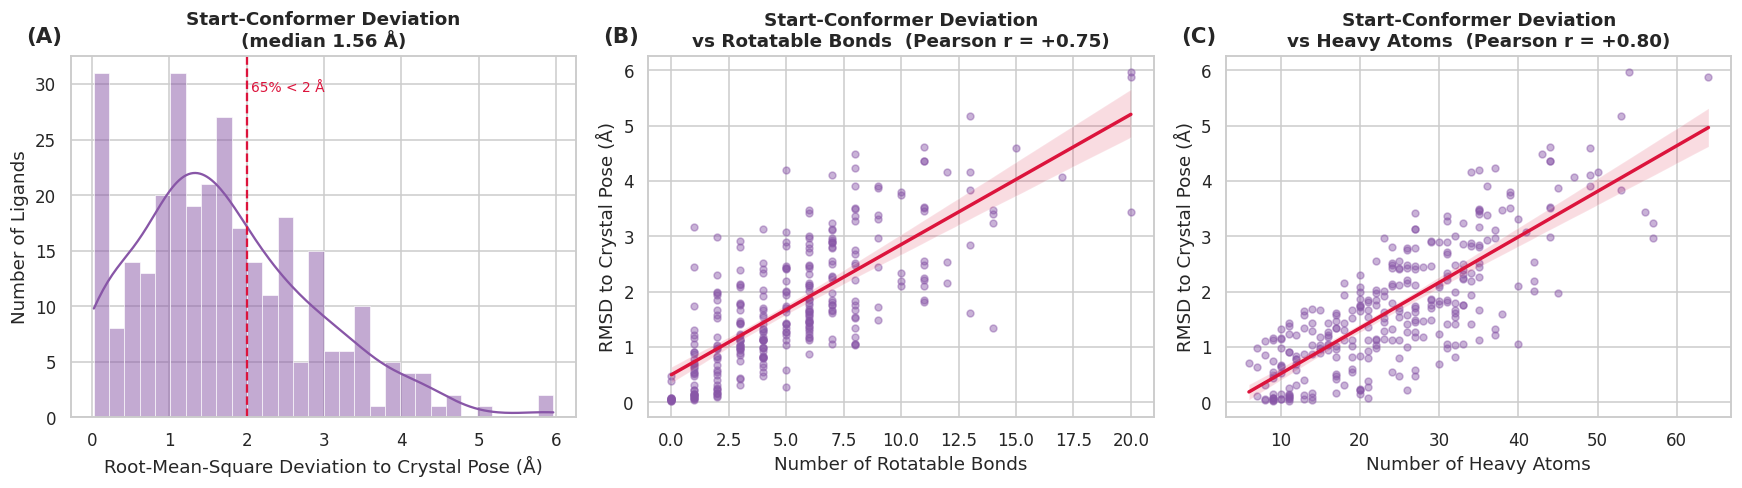

In [15]:
rmsd = df.dropna(subset=["startconf_rmsd"])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

sns.histplot(rmsd.startconf_rmsd, bins=30, kde=True, ax=axes[0], color="#8856a7",
             edgecolor="white", linewidth=.4)
axes[0].axvline(2.0, ls="--", color="crimson")
axes[0].set(title=f"Start-Conformer Deviation\n(median {rmsd.startconf_rmsd.median():.2f} Å)",
            xlabel=nice("startconf_rmsd"), ylabel="Number of Ligands")
axes[0].text(2.05, axes[0].get_ylim()[1]*0.9,
             f"{(rmsd.startconf_rmsd<2).mean()*100:.0f}% < 2 Å", color="crimson", fontsize=9)

for ax, x, ttl in [(axes[1], "rot_bonds", "vs Rotatable Bonds"),
                   (axes[2], "heavy_atoms", "vs Heavy Atoms")]:
    sns.regplot(data=rmsd, x=x, y="startconf_rmsd", ax=ax,
                scatter_kws=dict(s=20, alpha=.45, color="#8856a7"),
                line_kws=dict(color="crimson"))
    r = rmsd[[x, "startconf_rmsd"]].corr().iloc[0, 1]
    ax.set(title=f"Start-Conformer Deviation\n{ttl}  (Pearson r = {r:+.2f})",
           xlabel=nice(x), ylabel="RMSD to Crystal Pose (Å)")
_label_panels(axes)
savefig("08_startconf_rmsd"); plt.show()

## 10 · Summary of the mapping

Auto-generated headline numbers (re-computed from the table above).

In [16]:
def iqr(s): return f"{s.median():.1f} [{s.quantile(.25):.1f}–{s.quantile(.75):.1f}]"

print("PoseBusters Benchmark Set — distribution summary (median [IQR])")
print("="*64)
print(f"  Ligand heavy atoms      : {iqr(df.heavy_atoms)}   (range {df.heavy_atoms.min()}–{df.heavy_atoms.max()})")
print(f"  Molecular weight (Da)   : {iqr(df.mw)}")
print(f"  Rotatable bonds         : {iqr(df.rot_bonds)}")
print(f"  H-bond acc / don        : {iqr(df.hba)} / {iqr(df.hbd)}")
print(f"  TPSA (Å²)               : {iqr(df.tpsa)}")
print(f"  cLogP                   : {iqr(df.logp)}")
print(f"  Fraction sp3 C          : {iqr(df.fsp3)}")
print(f"  QED                     : {iqr(df.qed)}")
print("-"*64)
print(f"  Ro5 ≤1 violation        : {df.ro5_pass.mean()*100:.0f}% of ligands")
print(f"  Halogen / S / P present : {df.has_halogen.mean()*100:.0f}% / "
      f"{df.has_sulfur.mean()*100:.0f}% / {df.has_phosphorus.mean()*100:.0f}%")
print(f"  Net-charged ligands     : {(df.formal_charge!=0).mean()*100:.0f}%")
print("-"*64)
print(f"  Receptor residues       : {iqr(df.n_residues)}")
print(f"  Chains per complex      : {iqr(df.n_chains)}   (max {df.n_chains.max()})")
print(f"  Cofactor types > 0      : {(df.n_cofactor_types>0).mean()*100:.0f}% of complexes")
print("-"*64)
print(f"  Start-conf RMSD (Å)     : {iqr(df.startconf_rmsd.dropna())}")
print(f"  ... within 2 Å of xtal  : {(df.startconf_rmsd.dropna()<2).mean()*100:.0f}%")
print("="*64)
print(f"\nArtifacts written to: {OUT_DIR}/")
print(f"  - ligand_protein_features.csv  ({len(df)} rows x {df.shape[1]} cols)")
print(f"  - summary_statistics.csv")
print(f"  - figures/*.png  ({len(list(FIG_DIR.glob('*.png')))} figures)")


PoseBusters Benchmark Set — distribution summary (median [IQR])
  Ligand heavy atoms      : 24.0 [16.0–32.0]   (range 6–64)
  Molecular weight (Da)   : 359.4 [235.8–462.2]
  Rotatable bonds         : 5.0 [2.0–7.0]
  H-bond acc / don        : 6.0 [3.0–9.0] / 3.0 [2.0–5.0]
  TPSA (Å²)               : 106.6 [66.0–159.9]
  cLogP                   : 0.9 [-1.6–3.2]
  Fraction sp3 C          : 0.4 [0.2–0.6]
  QED                     : 0.4 [0.3–0.6]
----------------------------------------------------------------
  Ro5 ≤1 violation        : 83% of ligands
  Halogen / S / P present : 22% / 24% / 25%
  Net-charged ligands     : 3%
----------------------------------------------------------------
  Receptor residues       : 471.5 [306.2–777.5]
  Chains per complex      : 2.0 [1.0–2.0]   (max 40)
  Cofactor types > 0      : 89% of complexes
----------------------------------------------------------------
  Start-conf RMSD (Å)     : 1.6 [0.9–2.4]
  ... within 2 Å of xtal  : 65%

Artifacts written to

---
### Reading the maps — what the distributions say

- **Size & flexibility.** Ligands cluster around ~25 heavy atoms / ~365 Da but the set
  reaches well past 600 Da (peptides, nucleotides, macrocycles). Heavy-atom count and
  rotatable-bond count are strongly coupled — the dominant axis of docking difficulty.
- **Polarity is high and broad.** Median TPSA (~107 Å²) and the wide HBA/HBD spread
  reflect many highly polar, charged and sugar/nucleotide-like ligands — this is *not* a
  lead-like set, which is deliberate: it stresses generalisation.
- **Beyond Rule-of-Five.** A large minority violate ≥2 Ro5 criteria and median QED sits
  below the classic 0.34 "attractive" line, confirming the curated PDB diversity.
- **Composition.** Substantial fractions carry halogens, sulfur and phosphorus, and a
  meaningful share are net-charged — features that pose-validity checks (clashes,
  protonation, geometry) are sensitive to.
- **Receptors.** Mostly single/low-oligomer chains of a few hundred residues, with a long
  tail of large multi-chain assemblies, and most complexes retain cofactors.
- **Conformer difficulty.** Only a minority of ETKDGv3+UFF start conformers fall within
  2 Å of the crystal pose, and the gap widens with flexibility and size — quantifying the
  search burden placed on any docking method evaluated on this set.
